# 4D example

In [9]:
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt

In [10]:
#Define Jacobian matrix E= dF(0)/dz at origin
c = 10.33*0.33 - 1.33**2
E = np.array([[0,0,1,0],[0,0,0,1],
              [(1.33*5-0.33*55)/c,5/c,-0.33*5.5/c,-1.33*0.001/c],
              [(1.33*55-10.33*5)/c, -45/c, 1.33*5.5/c, 10.33*0.001/c]])

e,evecL,evecR = eig(E,left=True)

print(e)

[-0.31867823+5.36391306j -0.31867823-5.36391306j -0.23152604+2.2860475j
 -0.23152604-2.2860475j ]


In [11]:
# eigenvalues
eval1 = e[0]
eval2 = e[1]
eval3 = e[2]
eval4 = e[3]
# eigenvectors
w1 = evecL[:,0]
w2 = evecL[:,1]
w3 = evecL[:,2]
w4 = evecL[:,3]

In [12]:
#Define (z_1,z_2) grid

npoints = 60**2
X = np.random.uniform(-np.pi/12, np.pi/12, size=(npoints,4))

In [13]:
#Define functions F and G
def F(x):
    value1 = x[:,2]
    value2 = x[:,3]
    
    a = 2 * np.cos(x[:,1]) + 8.33
    b = np.cos(x[:,1]) + 0.33
    c = 0.33*a - b**2
    
    A = 5.5 * x[:,2] + 2 * x[:,2] * x[:,3] * np.sin(x[:,1]) + x[:,3]**2*np.sin(x[:,1]) - 50 * np.sin(x[:,0]) - 5*np.sin(x[:,0]+x[:,1])
    B = 0.001*x[:,3] - x[:,2]**2*np.sin(x[:,1]) - 5*np.sin(x[:,0]+x[:,1])
    value3 = (0.33 * A - b * B) / c
    value4 = (-b * B + a * A) / c
    return np.array([value1, value2, value3, value4]).T

# Define the function g using autograd's numpy (jnp)
def G(x):
    value = np.zeros((len(x),4))
    for i in range(len(x)):
        value[i,:] = np.dot(E, x[i,:])
    value = F(x)-value
    return value

In [14]:
# copute F and G at mesh grids
F_val = F(X)
G_val = G(X)

In [15]:
# number of features
N = 500
# scaling parameter
gamma = 0.000001

# right-hand side
y0 = np.zeros((5,1))
y1 = np.zeros((npoints,1))
for i in range(npoints):
    y1[i] = -G_val[i,:] @ w1
y = np.row_stack((y0,y1))

# Generate random features
# random feature matrix
Omega = np.random.normal(0, np.sqrt(2*gamma), size=(4,N) )
W_sum = np.sum(Omega, axis=1)
# generate amtrix A
A = np.zeros((npoints+5,N), dtype=np.complex128)
A[0,:] = np.ones(N)                   # h(0) = 0
A[1:5,:] = Omega         # h'(0) = 0
# linear pde
A[5:,:] = - 1j * F_val @ Omega * np.exp(1j * X @ Omega) - eval3 * np.exp(1j * X @ Omega) 

# solve optimization problem
c = np.linalg.pinv(A) @ y

/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.


In [16]:
# scipy ode
from scipy.integrate import odeint

def fun(y,t):
    
    x1, x2, x3, x4 = y
    
    a = 2 * np.cos(x2) + 8.33
    b = np.cos(x2) + 0.33
    c = 0.33*a - b**2
    
    A = 5.5 * x3 + 2 * x3 * x4 * np.sin(x2) + x4**2*np.sin(x2) - 50 * np.sin(x1) - 5*np.sin(x1+x2)
    B = 0.001*x4 - x3**2*np.sin(x2) - 5*np.sin(x1+x2)
    
    dydt = [x3, x4, (0.33*A-b*B)/c, (-b*A+a*B)/c ]
    return dydt

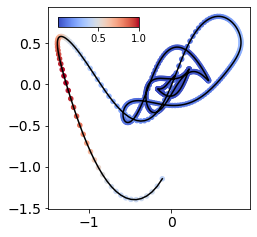

In [22]:
t = np.linspace(0, 10, 501)

#   0D initial values, directly from docs
y0_1 =np.random.uniform(-np.pi/12, np.pi/12, size=(4,))
sol_1 = odeint(fun, y0_1, t)

# estimate non-linear function h at mesh grids
K = np.exp(1j*sol_1 @ Omega)
y_test = K@c
# estimate eigenfunction
psi = y_test.reshape(-1) + w3[0] * sol_1[:,0] + w3[1] * sol_1[:,1] + w3[2] * sol_1[:,2] + w3[3] * sol_1[:,3]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create figure and single axes
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.1, 0.2, 0.8, 0.7])  # [left, bottom, width, height]

# Line plot (single color)
ax.plot(sol_1[:,0], sol_1[:,1], c='k') 
ax.set_aspect(aspect=1)

# Scatter plot with varying colors
sc = ax.scatter(sol_1[:,0], sol_1[:,1], c = abs(psi)/max(abs(psi)), cmap='coolwarm', s=20)

ax.tick_params(axis='both', labelsize=14)

# Colorbar inside the figure (manual positioning)
cax = inset_axes(ax, width="40%", height="5%", loc='upper left', borderpad=1)
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')

plt.savefig('plot4.pdf', bbox_inches = 'tight')

In [ ]:

plt.plot(sol_1[:,0], sol_1[:,1], c='k')                        
plt.scatter(sol_1[:,0], sol_1[:,1], c = abs(psi)/max(abs(psi)), cmap='coolwarm', s=20)
#plt.scatter(sol_1[:,0], sol_1[:,1], c=t, cmap="coolwarm")

plt.colorbar()